# 06 - Evaluation: generator quality, low-resource utility, and speed

This report-only notebook keeps three distinct questions separate:

1. **Part 1 - CRNN-only generator quality and seed stability:** Are refreshed VAE-v3 and diffusion samples classifier-compatible, distributionally similar to real clips, diverse, and stable across generation seeds?
2. **Part 2 - Matched low-resource CRNN utility:** With exactly 50 labeled real spectrograms per species, do generated additions of 50, 100, or 200 per species improve held-out classification across the preserved nine matched blocks?
3. **Part 3 - Generator-only speed:** How long do matched fresh in-memory VAE-v3 and DDIM diffusion requests take on the same CUDA hardware?

The final section reconciles those evidence types without treating quality, downstream utility, and speed as one score. Cached outputs are produced only from the finalized quality, protocol-4 low-resource, and generator-only speed report packages.

## tl;dr

These figures are tied to the finalized 2026-08-12 report packages loaded and validated below; this notebook does not retrain or regenerate samples.

- **Generator quality (CRNN and feature-space view):** Across three generation seeds, VAE-v3 reaches 96.66% mean CRNN macro F1 versus 92.42% for diffusion. Its mean Fréchet distance is 22.895 versus 41.255, with higher feature precision, recall, and coverage; diffusion's diversity ratio is closer to 1. These are not perceptual or waveform-realism scores.
- **Low-resource utility:** With 50 real spectrograms per species, validation selects +200 generated spectrograms per species for both generators. On the unchanged 489-clip test set, mean macro F1 is 84.75% for real-only, 87.48% for VAE-v3 (+2.72 points), and 86.21% for diffusion (+1.46 points) across nine matched blocks.
- **Generation speed:** For 600 fresh spectrograms per repeat on the recorded RTX 4070 SUPER, VAE-v3 averages 0.3058 seconds versus 412.3090 seconds for diffusion, a 1348.09x diffusion/VAE time ratio. This excludes loading, transfers, file I/O, and waveform decoding.
- **Interpretation:** These are separate evidence types. The notebook does not select a composite winner; it carries the classifier-view, nine-block, and sequential-timing limitations into the conclusion.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display


def locate_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'reports').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the bird_song_gen project root')


PROJECT_ROOT = locate_project_root(Path.cwd())
GENERATOR_COLORS = {'vae_v3': '#2E86AB', 'diffusion': '#E07A5F'}
MODEL_LABELS = {'vae_v3': 'VAE-v3', 'diffusion': 'Diffusion'}
MODEL_ORDER = ['vae_v3', 'diffusion']
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\Harvey\Documents\Coding\bird_song_gen


## Part 1 - CRNN-only generator quality and seed stability

**Question.** Before generated spectrograms are considered for classifier training, are the refreshed VAE-v3 and diffusion pools recognizable to the selected CRNN, close to real data in that CRNN feature space, sufficiently diverse, free of exact training copies, and stable across three generation seeds?

This section requires checkpoint-evaluation schema v3 and the selected CRNN as the sole evaluator. It reports classifier-view and array-level diagnostics, not waveform quality or human-perceived realism.

### Protocol and report reconciliation

In [2]:
CHECKPOINT_REPORT_ROOT = PROJECT_ROOT / 'reports' / 'generator_checkpoint_evaluation_2026-08-12'
required_checkpoint_files = [
    'summary.json', 'protocol.json', 'provenance.json', 'pool_audit.json',
    'classifier_scores.csv', 'metrics_per_seed.csv', 'metrics_aggregate.csv',
    'nearest_neighbor_summary.csv',
]
missing_checkpoint_files = [
    name for name in required_checkpoint_files if not (CHECKPOINT_REPORT_ROOT / name).is_file()
]
if missing_checkpoint_files:
    raise FileNotFoundError(
        f'Incomplete refreshed checkpoint report; missing: {missing_checkpoint_files}'
    )

checkpoint_summary = json.loads((CHECKPOINT_REPORT_ROOT / 'summary.json').read_text(encoding='utf-8'))
checkpoint_protocol = json.loads((CHECKPOINT_REPORT_ROOT / 'protocol.json').read_text(encoding='utf-8'))
checkpoint_provenance = json.loads((CHECKPOINT_REPORT_ROOT / 'provenance.json').read_text(encoding='utf-8'))
checkpoint_pool_audit = json.loads((CHECKPOINT_REPORT_ROOT / 'pool_audit.json').read_text(encoding='utf-8'))
classifier_scores = pd.read_csv(CHECKPOINT_REPORT_ROOT / 'classifier_scores.csv')
metrics_per_seed = pd.read_csv(CHECKPOINT_REPORT_ROOT / 'metrics_per_seed.csv')
metrics_aggregate = pd.read_csv(CHECKPOINT_REPORT_ROOT / 'metrics_aggregate.csv')
nearest_neighbor_summary = pd.read_csv(CHECKPOINT_REPORT_ROOT / 'nearest_neighbor_summary.csv')

assert {
    checkpoint_summary['schema_version'],
    checkpoint_protocol['schema_version'],
    checkpoint_provenance['schema_version'],
} == {3}
assert checkpoint_summary['classifier'] == checkpoint_protocol['classifier'] == 'crnn'
assert [item['classifier'] for item in checkpoint_provenance['evaluators']] == ['crnn']
assert checkpoint_pool_audit['schema_version'] == 1
expected_refresh_actions = {
    'vae_v3': 'filtered posterior bank and regenerated all three pools',
    'diffusion': 'reused audited DDIM pools; no diffusion spectrogram regeneration',
}
assert checkpoint_summary['refresh_actions'] == expected_refresh_actions
quality_vae_contract = checkpoint_protocol['generation_contracts']['vae_v3']
quality_diffusion_contract = checkpoint_protocol['generation_contracts']['diffusion']
assert quality_vae_contract['temperature'] == 0.35
assert quality_vae_contract['reparameterization'] == (
    'mu + temperature * exp(0.5 * logvar) * epsilon'
)
assert quality_vae_contract['posterior_bank_contract'] == (
    'content_safe_v2_train_filtered_existing_bank_v1'
)
assert quality_vae_contract['posterior_bank_counts'] == {
    'Northern Cardinal': 256, 'Song Sparrow': 247, 'American Robin': 256,
}
assert quality_vae_contract['posterior_bank_derivation'] == (
    'filtered_existing_posterior_bank'
)
assert quality_vae_contract['vae_checkpoint_retrained'] is False
assert quality_vae_contract['pool_reused_after_vae_bank_filter'] is False
assert quality_vae_contract['spectrograms_regenerated_after_vae_bank_filter'] is True
assert checkpoint_provenance['checkpoints']['vae_v3']['checkpoint_retrained_for_refresh'] is False
assert quality_diffusion_contract['sampler'] == 'ddim'
assert quality_diffusion_contract['timesteps'] == 1000
assert quality_diffusion_contract['ddim_steps'] == 100
assert quality_diffusion_contract['ddim_eta'] == 0.0
assert quality_diffusion_contract['guidance_weight'] == 3.0
assert quality_diffusion_contract['clamp_samples'] == 4.0
assert quality_diffusion_contract['checkpoint_epoch'] == 34
assert quality_diffusion_contract['checkpoint_selection'] == 'validation_best'
assert quality_diffusion_contract['stored_sampler_overridden'] == 'ddpm'
assert quality_diffusion_contract['pool_reused_after_vae_bank_filter'] is True
assert quality_diffusion_contract['spectrograms_regenerated_after_vae_bank_filter'] is False
quality_validation = checkpoint_protocol['validation_protocol']
assert checkpoint_protocol['validation_manifest'] == (
    'manifests/content_safe_v2/full_dataset_validation_generator_safe.csv'
)
assert quality_validation['validation_counts']['before']['rows'] == 519
assert quality_validation['validation_counts']['after'] == {
    'rows': 510,
    'species': {
        'American Robin': 163, 'Northern Cardinal': 172, 'Song Sparrow': 175,
    },
}
assert len(quality_validation['excluded_validation_relative_wav_paths']) == 9
assert quality_validation['test_unchanged']['rows'] == 489
assert quality_validation['test_unchanged']['excluded_rows'] == 0
assert checkpoint_provenance['validation_protocol'] == {
    'path': 'manifests/content_safe_v2/full_dataset_validation_generator_safe.protocol.json',
    'validation_rows': 510,
    'excluded_exact_historical_train_counterparts': 9,
    'test_rows_unchanged': 489,
}

checkpoint_models = set(checkpoint_protocol['models'])
checkpoint_seeds = set(checkpoint_protocol['seeds'])
checkpoint_species = set(checkpoint_protocol['class_order_generator'])
assert checkpoint_models == set(MODEL_ORDER)
assert checkpoint_seeds == {42, 123, 777}
assert checkpoint_protocol['samples_per_species'] == 200
for frame_name, frame in {
    'classifier_scores': classifier_scores,
    'metrics_per_seed': metrics_per_seed,
    'metrics_aggregate': metrics_aggregate,
    'nearest_neighbor_summary': nearest_neighbor_summary,
}.items():
    assert set(frame['classifier']) == {'crnn'}, frame_name

assert len(classifier_scores) == len(checkpoint_models) * len(checkpoint_seeds)
assert len(metrics_per_seed) == len(checkpoint_models) * len(checkpoint_seeds) * len(checkpoint_species)
assert len(metrics_aggregate) == len(checkpoint_models) * len(checkpoint_species)
assert len(nearest_neighbor_summary) == len(checkpoint_models) * len(checkpoint_seeds) * len(checkpoint_species)
expected_generated_arrays = (
    len(checkpoint_models) * len(checkpoint_seeds) * len(checkpoint_species)
    * checkpoint_protocol['samples_per_species']
)
assert checkpoint_summary['generated_arrays_total'] == expected_generated_arrays
assert checkpoint_summary['seed_count'] == len(checkpoint_seeds)
expected_pool_size = len(checkpoint_species) * checkpoint_protocol['samples_per_species']
assert all(
    pool['sample_count'] == expected_pool_size
    for model_audit in checkpoint_pool_audit['models'].values()
    for pool in model_audit['pools']
)

calibration_table = pd.DataFrame(checkpoint_summary['calibration'])
assert set(calibration_table['classifier']) == {'crnn'}
assert np.allclose(calibration_table['accuracy'], calibration_table['expected_accuracy'], atol=1e-12)
assert np.allclose(calibration_table['macro_f1'], calibration_table['expected_macro_f1'], atol=1e-12)

protocol_table = pd.DataFrame([
    {'item': 'Report schema', 'recorded value': checkpoint_protocol['schema_version']},
    {'item': 'Models', 'recorded value': ', '.join(checkpoint_protocol['models'])},
    {'item': 'Generation seeds', 'recorded value': ', '.join(map(str, checkpoint_protocol['seeds']))},
    {'item': 'Samples per species / seed', 'recorded value': checkpoint_protocol['samples_per_species']},
    {'item': 'Total arrays', 'recorded value': checkpoint_summary['generated_arrays_total']},
    {'item': 'Generator-safe validation rows', 'recorded value': 510},
    {'item': 'Unchanged held-out test rows', 'recorded value': 489},
    {'item': 'Evaluator', 'recorded value': checkpoint_protocol['classifier']},
    {'item': 'Feature projection', 'recorded value': 'StandardScaler + 64-component PCA on content-safe train'},
    {'item': 'Resampling', 'recorded value': '200 resamples of 128 real + 128 generated per species'},
])
display(protocol_table)
refresh_table = pd.DataFrame([
    {
        'model': MODEL_LABELS['vae_v3'],
        'pool action': expected_refresh_actions['vae_v3'],
        'checkpoint retrained': False,
    },
    {
        'model': MODEL_LABELS['diffusion'],
        'pool action': expected_refresh_actions['diffusion'],
        'checkpoint retrained': False,
    },
])
display(refresh_table)
display(calibration_table[[
    'classifier', 'sample_count', 'accuracy', 'macro_f1', 'macro_recall',
    'mean_confidence', 'mean_entropy',
]].style.format({
    'accuracy': '{:.2%}', 'macro_f1': '{:.2%}', 'macro_recall': '{:.2%}',
    'mean_confidence': '{:.3f}', 'mean_entropy': '{:.3f}',
}))

checkpoint_table = pd.DataFrame([
    {
        'model': model,
        'parameter_count': details['parameter_count'],
        'checkpoint_path': details['path'],
        'ema_used': details.get('ema_state_dict', False),
    }
    for model, details in checkpoint_provenance['checkpoints'].items()
])
display(checkpoint_table)

,item,recorded value
0,Report schema,3
1,Models,"vae_v3, diffusion"
2,Generation seeds,"42, 123, 777"
3,Samples per species / seed,200
4,Total arrays,3600
5,Generator-safe validation rows,510
6,Unchanged held-out test rows,489
7,Evaluator,crnn
8,Feature projection,StandardScaler + 64-component PCA on content-s...
9,Resampling,200 resamples of 128 real + 128 generated per ...


,model,pool action,checkpoint retrained
0,VAE-v3,filtered posterior bank and regenerated all th...,False
1,Diffusion,reused audited DDIM pools; no diffusion spectr...,False


,classifier,sample_count,accuracy,macro_f1,macro_recall,mean_confidence,mean_entropy
0,crnn,489,89.98%,90.16%,90.18%,0.921,0.263


,model,parameter_count,checkpoint_path,ema_used
0,vae_v3,5365025,artifacts/models/vae/conditional_vae_v3/condit...,False
1,diffusion,18443841,C:\Users\Harvey\Desktop\conditional_diffusion\...,True


### Target-label accuracy, macro F1/recall, and seed stability

,model,seed,sample_count,target_label_accuracy,macro_f1,macro_recall,mean_confidence,mean_entropy
3,diffusion,42,600,91.50%,91.48%,91.50%,0.924,0.246
4,diffusion,123,600,92.67%,92.64%,92.67%,0.929,0.234
5,diffusion,777,600,93.17%,93.13%,93.17%,0.940,0.213
0,vae_v3,42,600,96.33%,96.31%,96.33%,0.941,0.216
1,vae_v3,123,600,95.67%,95.66%,95.67%,0.938,0.220
2,vae_v3,777,600,98.00%,98.00%,98.00%,0.944,0.214


,model,target_accuracy_mean,target_accuracy_sample_sd,macro_f1_mean,macro_f1_sample_sd,macro_f1_min,macro_f1_max,macro_recall_mean
0,diffusion,92.44%,0.86%,92.42%,0.84%,91.48%,93.13%,92.44%
1,vae_v3,96.67%,1.20%,96.66%,1.21%,95.66%,98.00%,96.67%


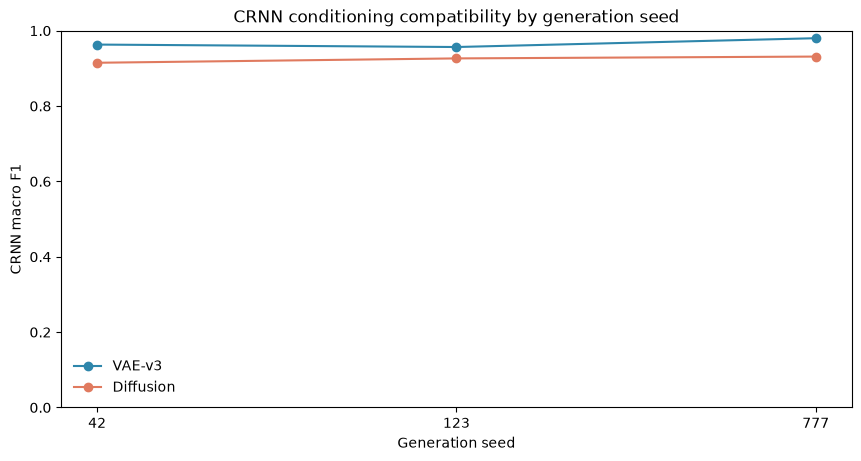

In [3]:
target_accuracy_by_seed = (
    metrics_per_seed.groupby(['model', 'seed'], as_index=False)
    .agg(target_label_accuracy=('target_label_accuracy', 'mean'))
)
seed_scores = classifier_scores.merge(
    target_accuracy_by_seed, on=['model', 'seed'], validate='one_to_one'
)
assert np.allclose(seed_scores['accuracy'], seed_scores['target_label_accuracy'], atol=1e-12)
display(seed_scores[[
    'model', 'seed', 'sample_count', 'target_label_accuracy', 'macro_f1',
    'macro_recall', 'mean_confidence', 'mean_entropy',
]].sort_values(['model', 'seed']).style.format({
    'target_label_accuracy': '{:.2%}', 'macro_f1': '{:.2%}',
    'macro_recall': '{:.2%}', 'mean_confidence': '{:.3f}', 'mean_entropy': '{:.3f}',
}))

part1_model_summary = (
    seed_scores.groupby('model', as_index=False)
    .agg(
        target_accuracy_mean=('target_label_accuracy', 'mean'),
        target_accuracy_sample_sd=('target_label_accuracy', 'std'),
        macro_f1_mean=('macro_f1', 'mean'),
        macro_f1_sample_sd=('macro_f1', 'std'),
        macro_f1_min=('macro_f1', 'min'),
        macro_f1_max=('macro_f1', 'max'),
        macro_recall_mean=('macro_recall', 'mean'),
    )
)
display(part1_model_summary.style.format({
    column: '{:.2%}' for column in part1_model_summary.columns if column != 'model'
}))

figure, axis = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
for model in MODEL_ORDER:
    frame = seed_scores[seed_scores['model'] == model].sort_values('seed')
    axis.plot(
        frame['seed'].astype(str), frame['macro_f1'], marker='o',
        color=GENERATOR_COLORS[model], label=MODEL_LABELS[model],
    )
axis.set(
    xlabel='Generation seed', ylabel='CRNN macro F1', ylim=(0, 1),
    title='CRNN conditioning compatibility by generation seed',
)
axis.legend(frameon=False)
plt.show()

### Feature fidelity, manifold support, diversity, copy risk, and pixel diagnostics

Fréchet distance, precision, recall, density, coverage, and diversity are computed only in the selected CRNN feature space. Pixel and gradient summaries are array-level diagnostics. Neither family is a perceptual audio score.

,model,species,target_label_accuracy_mean,species_recall_mean,species_f1_mean,macro_f1_mean,frechet_mean_mean,precision_mean_mean,recall_mean_mean,density_mean_mean,coverage_mean_mean,generated_diversity_mean_mean,diversity_ratio_mean_mean,diversity_delta_mean_mean
0,diffusion,American Robin,94.00%,94.00%,93.53%,92.42%,29.706,49.14%,81.97%,0.257,48.54%,10.291,1.058,+0.561
1,diffusion,Northern Cardinal,84.33%,84.33%,91.33%,92.42%,39.655,81.81%,85.22%,0.514,63.70%,14.864,1.011,+0.159
2,diffusion,Song Sparrow,99.00%,99.00%,92.39%,92.42%,54.403,38.65%,79.01%,0.164,33.12%,10.750,0.956,-0.507
3,vae_v3,American Robin,99.67%,99.67%,97.01%,96.66%,13.803,75.27%,87.01%,0.475,66.61%,8.427,0.866,-1.303
4,vae_v3,Northern Cardinal,96.67%,96.67%,97.48%,96.66%,42.935,90.62%,90.62%,0.704,71.72%,11.543,0.785,-3.161
5,vae_v3,Song Sparrow,93.67%,93.67%,95.49%,96.66%,11.947,89.94%,91.54%,0.748,84.25%,10.844,0.964,-0.414


,Generator,target_label_accuracy,macro_f1,frechet_distance,feature_precision,feature_recall,density,coverage,diversity_ratio,pixel_wasserstein
0,Diffusion,92.44%,92.42%,41.255,56.54%,82.07%,0.311,48.45%,1.008,0.1916
1,VAE-v3,96.67%,96.66%,22.895,85.28%,89.72%,0.642,74.19%,0.872,0.0787


,model,species,generated_count,exact_train_duplicates,validation_threshold,nearest_train_distance_median,below_threshold_fraction
0,diffusion,American Robin,200,0,2.064,4.026,0.00%
1,diffusion,Northern Cardinal,200,0,2.666,4.227,5.67%
2,diffusion,Song Sparrow,200,0,2.505,4.297,1.83%
3,vae_v3,American Robin,200,0,2.064,2.820,17.00%
4,vae_v3,Northern Cardinal,200,0,2.666,2.712,49.00%
5,vae_v3,Song Sparrow,200,0,2.505,2.675,44.00%


,model,species,real_time_gradient_energy_mean,generated_time_gradient_energy_mean,real_frequency_gradient_energy_mean,generated_frequency_gradient_energy_mean,real_dynamic_range_mean,generated_dynamic_range_mean,real_active_bin_fraction_mean,generated_active_bin_fraction_mean,real_pixel_mean_mean,generated_pixel_mean_mean,real_pixel_std_mean,generated_pixel_std_mean,pixel_distribution_wasserstein_mean,pixel_mean_delta_mean,pixel_std_delta_mean
0,diffusion,American Robin,0.092,0.078,0.070,0.061,1.965,1.958,0.864,0.727,-0.401,-0.308,0.375,0.554,0.191,0.093,0.180
1,diffusion,Northern Cardinal,0.108,0.084,0.072,0.054,1.963,1.840,0.921,0.833,-0.265,-0.237,0.387,0.490,0.114,0.028,0.104
2,diffusion,Song Sparrow,0.103,0.070,0.075,0.056,1.874,1.957,0.962,0.658,-0.225,-0.383,0.336,0.568,0.270,-0.158,0.232
3,vae_v3,American Robin,0.092,0.076,0.070,0.041,1.965,1.974,0.864,0.905,-0.401,-0.304,0.375,0.372,0.097,0.097,-0.003
4,vae_v3,Northern Cardinal,0.108,0.088,0.072,0.043,1.963,1.937,0.921,0.955,-0.265,-0.184,0.387,0.342,0.090,0.081,-0.045
5,vae_v3,Song Sparrow,0.103,0.078,0.075,0.041,1.874,1.942,0.962,0.899,-0.225,-0.268,0.336,0.378,0.049,-0.043,0.042


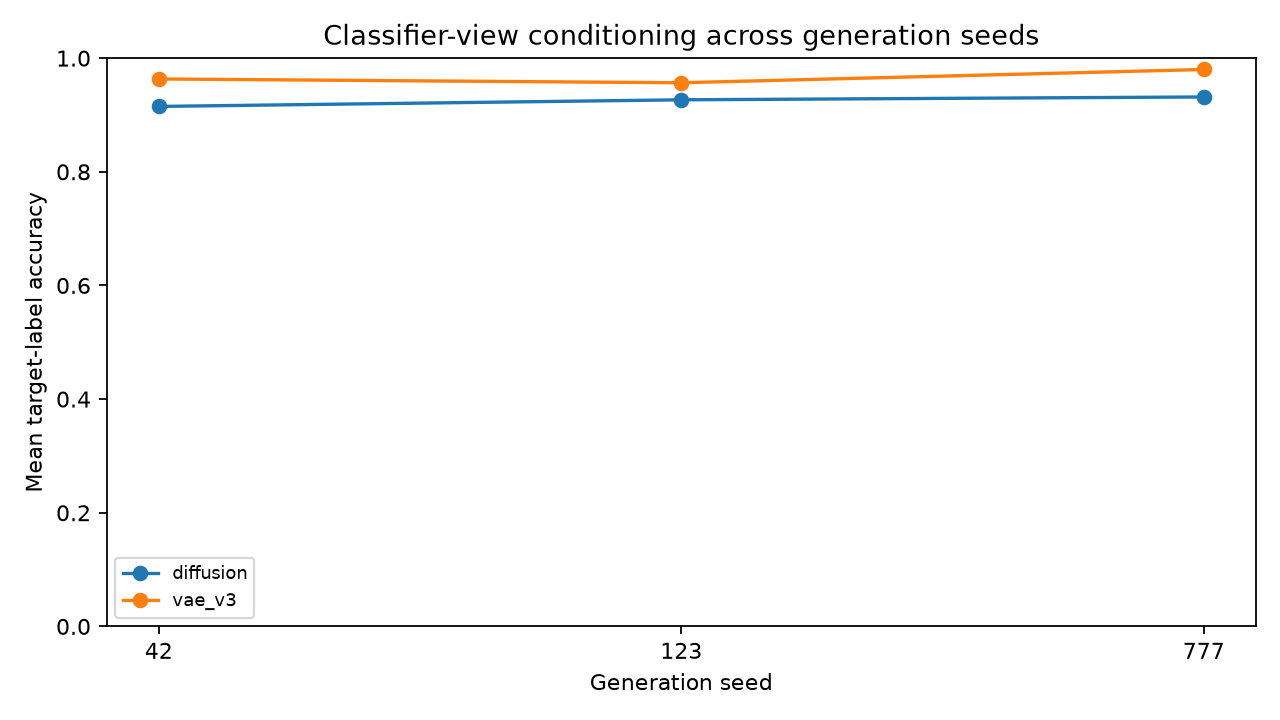

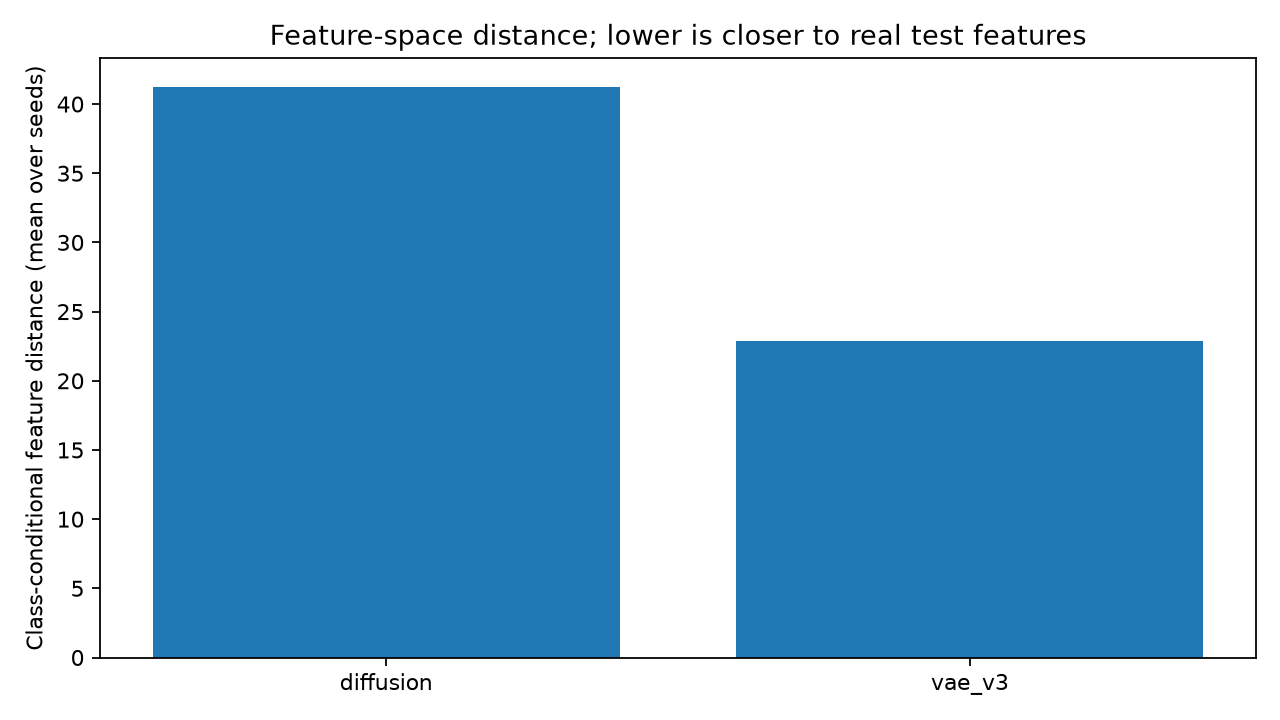

In [4]:
quality_columns = [
    'model', 'species', 'target_label_accuracy_mean', 'species_recall_mean',
    'species_f1_mean', 'macro_f1_mean', 'frechet_mean_mean',
    'precision_mean_mean', 'recall_mean_mean', 'density_mean_mean',
    'coverage_mean_mean', 'generated_diversity_mean_mean',
    'diversity_ratio_mean_mean', 'diversity_delta_mean_mean',
]
missing_quality_columns = set(quality_columns) - set(metrics_aggregate.columns)
assert not missing_quality_columns, missing_quality_columns
display(metrics_aggregate[quality_columns].sort_values(['model', 'species']).style.format({
    'target_label_accuracy_mean': '{:.2%}', 'species_recall_mean': '{:.2%}',
    'species_f1_mean': '{:.2%}', 'macro_f1_mean': '{:.2%}',
    'frechet_mean_mean': '{:.3f}', 'precision_mean_mean': '{:.2%}',
    'recall_mean_mean': '{:.2%}', 'density_mean_mean': '{:.3f}',
    'coverage_mean_mean': '{:.2%}', 'generated_diversity_mean_mean': '{:.3f}',
    'diversity_ratio_mean_mean': '{:.3f}', 'diversity_delta_mean_mean': '{:+.3f}',
}))

# Equal generated counts make an unweighted mean over the three species a
# compact model-level summary of the recorded feature diagnostics.
quality_model_summary = (
    metrics_aggregate.groupby('model', as_index=False)
    .agg(
        target_label_accuracy=('target_label_accuracy_mean', 'mean'),
        macro_f1=('macro_f1_mean', 'mean'),
        frechet_distance=('frechet_mean_mean', 'mean'),
        feature_precision=('precision_mean_mean', 'mean'),
        feature_recall=('recall_mean_mean', 'mean'),
        density=('density_mean_mean', 'mean'),
        coverage=('coverage_mean_mean', 'mean'),
        diversity_ratio=('diversity_ratio_mean_mean', 'mean'),
        pixel_wasserstein=('pixel_distribution_wasserstein_mean', 'mean'),
    )
    .rename(columns={'model': 'Generator'})
)
quality_model_summary['Generator'] = quality_model_summary['Generator'].map(MODEL_LABELS)
display(quality_model_summary.sort_values('Generator').style.format({
    'target_label_accuracy': '{:.2%}', 'macro_f1': '{:.2%}',
    'frechet_distance': '{:.3f}', 'feature_precision': '{:.2%}',
    'feature_recall': '{:.2%}', 'density': '{:.3f}',
    'coverage': '{:.2%}', 'diversity_ratio': '{:.3f}',
    'pixel_wasserstein': '{:.4f}',
}))

copy_risk_view = (
    nearest_neighbor_summary.groupby(['model', 'species'], as_index=False)
    .agg(
        generated_count=('generated_count', 'max'),
        exact_train_duplicates=('exact_train_duplicate_count', 'max'),
        validation_threshold=('copy_risk_threshold', 'mean'),
        nearest_train_distance_median=('nearest_train_median', 'mean'),
        below_threshold_fraction=('below_threshold_fraction', 'mean'),
    )
)
display(copy_risk_view.sort_values(['model', 'species']).style.format({
    'validation_threshold': '{:.3f}',
    'nearest_train_distance_median': '{:.3f}',
    'below_threshold_fraction': '{:.2%}',
}))

pixel_columns = [
    'model', 'species',
    'real_time_gradient_energy_mean', 'generated_time_gradient_energy_mean',
    'real_frequency_gradient_energy_mean', 'generated_frequency_gradient_energy_mean',
    'real_dynamic_range_mean', 'generated_dynamic_range_mean',
    'real_active_bin_fraction_mean', 'generated_active_bin_fraction_mean',
    'real_pixel_mean_mean', 'generated_pixel_mean_mean',
    'real_pixel_std_mean', 'generated_pixel_std_mean',
    'pixel_distribution_wasserstein_mean', 'pixel_mean_delta_mean', 'pixel_std_delta_mean',
]
missing_pixel_columns = set(pixel_columns) - set(metrics_aggregate.columns)
assert not missing_pixel_columns, missing_pixel_columns
display(metrics_aggregate[pixel_columns].sort_values(['model', 'species']).style.format({
    column: '{:.3f}' for column in pixel_columns[2:]
}))

for figure_name in ('conditioning_by_seed.png', 'feature_distance_summary.png'):
    figure_path = CHECKPOINT_REPORT_ROOT / 'figures' / figure_name
    if figure_path.is_file():
        display(Image(filename=str(figure_path), width=720))

### Part 1 evidence boundary

The next cell deliberately reports refreshed values without a prewritten winner. Interpret seed means together with their spread, feature-space metrics, copy-risk screen, and pixel diagnostics. These results can support statements about CRNN compatibility, conditioning, feature-space similarity, diversity, coverage, copying risk, and generation-seed stability. They cannot establish waveform quality, human realism, generator training stability, or downstream augmentation benefit.

In [5]:
part1_copy_summary = (
    copy_risk_view.groupby('model', as_index=False)
    .agg(
        exact_train_duplicates=('exact_train_duplicates', 'max'),
        below_threshold_fraction_mean=('below_threshold_fraction', 'mean'),
    )
)
part1_evidence = part1_model_summary.merge(part1_copy_summary, on='model', validate='one_to_one')
display(part1_evidence.style.format({
    'target_accuracy_mean': '{:.2%}', 'target_accuracy_sample_sd': '{:.2%}',
    'macro_f1_mean': '{:.2%}', 'macro_f1_sample_sd': '{:.2%}',
    'macro_f1_min': '{:.2%}', 'macro_f1_max': '{:.2%}',
    'macro_recall_mean': '{:.2%}', 'below_threshold_fraction_mean': '{:.2%}',
}))
for row in part1_evidence.sort_values('model').itertuples(index=False):
    print(
        f'{MODEL_LABELS[row.model]}: CRNN macro F1 {row.macro_f1_mean:.2%} '        f'(seed range {row.macro_f1_min:.2%} to {row.macro_f1_max:.2%}); '        f'exact train duplicates {int(row.exact_train_duplicates)}; '        f'mean below-threshold fraction {row.below_threshold_fraction_mean:.2%}.'
    )

,model,target_accuracy_mean,target_accuracy_sample_sd,macro_f1_mean,macro_f1_sample_sd,macro_f1_min,macro_f1_max,macro_recall_mean,exact_train_duplicates,below_threshold_fraction_mean
0,diffusion,92.44%,0.86%,92.42%,0.84%,91.48%,93.13%,92.44%,0,2.50%
1,vae_v3,96.67%,1.20%,96.66%,1.21%,95.66%,98.00%,96.67%,0,36.67%


Diffusion: CRNN macro F1 92.42% (seed range 91.48% to 93.13%); exact train duplicates 0; mean below-threshold fraction 2.50%.
VAE-v3: CRNN macro F1 96.66% (seed range 95.66% to 98.00%); exact train duplicates 0; mean below-threshold fraction 36.67%.


## Part 2 - Matched low-resource CRNN utility

**Question.** If a newly initialized CRNN can see only 50 labeled real spectrograms per species, do refreshed VAE-v3 or diffusion pools improve classification of real held-out clips?

This section preserves the exact 50+0/50/100/200 design and the same nine matched real-subset/training-seed blocks. It reads only the refreshed matched-study report under `reports/crnn_low_resource_augmentation_2026-08-12/`.

In [6]:
LOW_RESOURCE_REPORT_ROOT = PROJECT_ROOT / 'reports' / 'crnn_low_resource_augmentation_2026-08-12'
required_low_resource_files = [
    'protocol.json', 'summary.json', 'provenance.json', 'input_audit.json',
    'validation_per_run.csv', 'validation_selection.csv',
    'test_aggregate.csv', 'test_per_run.csv', 'paired_deltas.csv',
    'paired_summary.csv', 'subset_membership.csv', 'subset_overlap.csv',
]
missing_low_resource_files = [
    name for name in required_low_resource_files
    if not (LOW_RESOURCE_REPORT_ROOT / name).is_file()
]
if missing_low_resource_files:
    raise FileNotFoundError(
        f'Incomplete refreshed low-resource report; missing: {missing_low_resource_files}'
    )

low_protocol = json.loads((LOW_RESOURCE_REPORT_ROOT / 'protocol.json').read_text(encoding='utf-8'))
low_summary = json.loads((LOW_RESOURCE_REPORT_ROOT / 'summary.json').read_text(encoding='utf-8'))
low_provenance = json.loads((LOW_RESOURCE_REPORT_ROOT / 'provenance.json').read_text(encoding='utf-8'))
low_input_audit = json.loads((LOW_RESOURCE_REPORT_ROOT / 'input_audit.json').read_text(encoding='utf-8'))
low_validation_per_run = pd.read_csv(LOW_RESOURCE_REPORT_ROOT / 'validation_per_run.csv')
low_validation = pd.read_csv(LOW_RESOURCE_REPORT_ROOT / 'validation_selection.csv')
low_test_aggregate = pd.read_csv(LOW_RESOURCE_REPORT_ROOT / 'test_aggregate.csv')
low_test_per_run = pd.read_csv(LOW_RESOURCE_REPORT_ROOT / 'test_per_run.csv')
low_paired = pd.read_csv(LOW_RESOURCE_REPORT_ROOT / 'paired_deltas.csv')
low_paired_summary = pd.read_csv(LOW_RESOURCE_REPORT_ROOT / 'paired_summary.csv')
low_membership = pd.read_csv(LOW_RESOURCE_REPORT_ROOT / 'subset_membership.csv')
low_subset_overlap = pd.read_csv(LOW_RESOURCE_REPORT_ROOT / 'subset_overlap.csv')

selected_ratios = {key: int(value) for key, value in low_protocol['selected_ratios'].items()}
condition_codes = {
    'real_only': 'real_only',
    **{model: f'{model}_plus_{selected_ratios[model]}' for model in MODEL_ORDER},
}
LOW_RESOURCE_CONDITION_LABELS = {
    'real_only': 'Real only',
    **{
        condition_codes[model]: f'{MODEL_LABELS[model]} +{selected_ratios[model]}'
        for model in MODEL_ORDER
    },
}
LOW_RESOURCE_COLORS = {
    'Real only': '#5B6770',
    **{
        LOW_RESOURCE_CONDITION_LABELS[condition_codes[model]]: GENERATOR_COLORS[model]
        for model in MODEL_ORDER
    },
}
print(f'Low-resource report: {LOW_RESOURCE_REPORT_ROOT.relative_to(PROJECT_ROOT)}')

Low-resource report: reports\crnn_low_resource_augmentation_2026-08-12


### Exact nine-block protocol audit

In [7]:
assert low_protocol['schema_version'] == 2
assert low_summary['schema_version'] == 2
assert low_provenance['schema_version'] == 2
assert low_input_audit['schema_version'] == 2
assert low_input_audit['pool_audit']['schema_version'] == 2
assert {
    low_protocol['protocol_version'], low_summary['protocol_version'],
    low_provenance['protocol_version'], low_input_audit['protocol_version'],
    low_protocol['training_protocol']['protocol_version'],
} == {4}
assert low_protocol['training_protocol']['architecture'] == 'crnn'
assert low_protocol['checkpoint_count'] == 63
assert low_protocol['real_per_species'] == 50
assert low_protocol['ratios_per_species'] == [50, 100, 200]
assert low_protocol['real_subset_seeds'] == [101, 202, 303]
assert low_protocol['train_seeds'] == [42, 123, 777]
assert low_protocol['pool_seeds'] == [42, 123, 777]
low_validation_identity = low_protocol['validation_protocol_identity']
assert low_validation_identity == low_input_audit['validation_protocol_identity']
assert low_protocol['validation_manifest'] == (
    'manifests/content_safe_v2/full_dataset_validation_generator_safe.csv'
)
assert low_protocol['test_manifest'] == 'manifests/content_safe_v2/full_dataset_test.csv'
assert low_validation_identity['validation_counts']['before']['rows'] == 519
assert low_validation_identity['validation_counts']['after'] == {
    'rows': 510,
    'species': {
        'American Robin': 163, 'Northern Cardinal': 172, 'Song Sparrow': 175,
    },
}
assert len(low_validation_identity['excluded_validation_relative_wav_paths']) == 9
assert low_validation_identity['test_unchanged']['rows'] == 489
assert low_validation_identity['test_unchanged']['excluded_rows'] == 0
low_evidence_boundaries = {
    'generator_safe_validation_rows': 510, 'held_out_test_rows': 489,
}
assert low_protocol['evidence_boundaries'] == low_evidence_boundaries
assert low_summary['evidence_boundaries'] == low_evidence_boundaries
assert {
    key: low_provenance['evidence_boundaries'][key]
    for key in low_evidence_boundaries
} == low_evidence_boundaries
assert low_provenance['evidence_boundaries']['checkpoint_count'] == 63
assert (
    low_provenance['evidence_boundaries']['validation_protocol_identity']
    == low_validation_identity
)
low_pool_provenance = low_protocol['pool_provenance']
assert low_pool_provenance == low_summary['pool_provenance'] == low_provenance['pool_provenance']
assert low_pool_provenance['source_schema_version'] == 3
assert low_pool_provenance['low_resource_pool_generation_performed'] is False
low_vae_pool = low_pool_provenance['models']['vae_v3']
low_diffusion_pool = low_pool_provenance['models']['diffusion']
for pool_record in (low_vae_pool, low_diffusion_pool):
    assert pool_record['pool_seeds'] == [42, 123, 777]
    assert pool_record['samples_per_pool'] == 600
low_vae_contract = low_vae_pool['generation_contract']
assert low_vae_contract['temperature'] == quality_vae_contract['temperature'] == 0.35
assert low_vae_contract['reparameterization'] == quality_vae_contract['reparameterization']
assert low_vae_contract['posterior_bank_contract'] == quality_vae_contract['posterior_bank_contract']
assert low_vae_contract['posterior_bank_counts'] == quality_vae_contract['posterior_bank_counts']
assert low_vae_contract['posterior_bank_derivation'] == 'filtered_existing_posterior_bank'
assert low_vae_contract['vae_checkpoint_retrained'] is False
assert low_vae_pool['checkpoint_not_retrained'] is True
assert low_vae_pool['pool_reused_after_vae_bank_filter'] is False
assert low_vae_pool['spectrograms_regenerated_after_vae_bank_filter'] is True
low_diffusion_contract = low_diffusion_pool['generation_contract']
for key in (
    'sampler', 'timesteps', 'ddim_steps', 'ddim_eta', 'guidance_weight',
    'clamp_samples', 'checkpoint_epoch', 'checkpoint_selection',
    'stored_sampler_overridden',
):
    assert low_diffusion_contract[key] == quality_diffusion_contract[key]
assert low_diffusion_pool['pool_reused_after_vae_bank_filter'] is True
assert low_diffusion_pool['spectrograms_regenerated_after_vae_bank_filter'] is False
assert len(low_input_audit['pool_details']) == 6
for pool_detail in low_input_audit['pool_details']:
    generation = pool_detail['generation_identity']['generation']
    assert generation['schema_version'] == 3
    assert generation['generator'] == pool_detail['model']
    assert generation['seed'] == pool_detail['seed']
    assert generation['samples_per_class'] == 200
    assert pool_detail['rows'] == 600
    if pool_detail['model'] == 'vae_v3':
        assert generation['temperature'] == low_vae_contract['temperature']
        assert generation['posterior_bank_contract'] == low_vae_contract['posterior_bank_contract']
        assert generation['posterior_bank_counts'] == low_vae_contract['posterior_bank_counts']
        assert generation['vae_checkpoint_retrained'] is False
    else:
        for key in (
            'sampler', 'ddim_steps', 'ddim_eta', 'guidance_weight',
            'clamp_samples', 'checkpoint_epoch', 'checkpoint_selection',
            'stored_sampler_overridden',
        ):
            assert generation[key] == low_diffusion_contract[key]
expected_blocks = [
    (101, 42, 42), (101, 123, 123), (101, 777, 777),
    (202, 42, 123), (202, 123, 777), (202, 777, 42),
    (303, 42, 777), (303, 123, 42), (303, 777, 123),
]
observed_blocks = [
    (
        int(block['real_subset_seed']),
        int(block['train_seed']),
        int(block['pool_seed']),
    )
    for block in low_protocol['replicate_blocks']
]
assert observed_blocks == expected_blocks
assert low_summary['selected_ratios'] == low_protocol['selected_ratios']

expected_validation = {
    (generator, ratio)
    for generator in MODEL_ORDER
    for ratio in (50, 100, 200)
}
assert set(zip(low_validation['generator'], low_validation['ratio_per_species'])) == expected_validation
assert low_validation['runs'].eq(9).all()
assert len(low_validation_per_run) == 63
expected_validation_conditions = {'real_only'}
for model in MODEL_ORDER:
    expected_validation_conditions.update(
        f'{model}_plus_{ratio}' for ratio in low_protocol['ratios_per_species']
    )
assert set(low_validation_per_run['condition']) == expected_validation_conditions
assert low_validation_per_run['condition'].value_counts().eq(9).all()
selected_validation_rows = low_validation[
    low_validation['selected_for_test'].astype(str).str.lower().eq('true')
]
selected_from_validation = {
    row.generator: int(row.ratio_per_species)
    for row in selected_validation_rows.itertuples(index=False)
}
assert selected_from_validation == selected_ratios
assert set(low_test_aggregate['condition']) == set(LOW_RESOURCE_CONDITION_LABELS)
assert low_test_aggregate['runs'].eq(9).all()
assert len(low_test_per_run) == 27
assert low_test_per_run['sample_count'].eq(489).all()
assert len(low_paired) == 18
assert set(low_paired_summary['generator']) == set(MODEL_ORDER)
assert low_paired_summary['paired_blocks'].eq(9).all()

membership_counts = low_membership.groupby(['low_resource_subset_seed', 'name']).size()
recording_counts = low_membership.groupby(['low_resource_subset_seed', 'name'])['id'].nunique()
assert membership_counts.eq(50).all()
assert recording_counts.eq(50).all()
assert len(low_membership) == 450
assert len(low_subset_overlap) == 9
total_training_runs = int(low_validation['runs'].sum()) + 9
assert total_training_runs == 63

audit = pd.DataFrame({
    'Check': [
        'Protocol version', 'Matched blocks', 'Conditions per block',
        'Total CRNN training runs', 'Held-out evaluations',
        'Generator-safe validation clips', 'Test clips per evaluation',
        'Real subset rows', 'Distinct recording IDs per subset/species',
        'VAE checkpoint retrained', 'Diffusion pools regenerated',
    ],
    'Observed': [4, 9, 7, total_training_runs, 27, 510, 489, 450, 50, False, False],
    'Status': ['pass'] * 11,
})
display(audit)

,Check,Observed,Status
0,Protocol version,4,pass
1,Matched blocks,9,pass
2,Conditions per block,7,pass
3,Total CRNN training runs,63,pass
4,Held-out evaluations,27,pass
5,Generator-safe validation clips,510,pass
6,Test clips per evaluation,489,pass
7,Real subset rows,450,pass
8,Distinct recording IDs per subset/species,50,pass
9,VAE checkpoint retrained,False,pass


### Experimental design

Each block trains the same from-scratch CRNN under seven conditions: real-only (50+0) and VAE-v3 or diffusion additions of 50, 100, or 200 per species. The three real-subset seeds and three CRNN initialization seeds form nine matched blocks; generation-pool seeds rotate by the preserved Latin square. Ratio selection uses the 510-row generator-safe validation split, while the 489-row test split remains unchanged and is used only for the real-only controls and the two selected arms. The low-resource workflow generated no pools: it consumed regenerated VAE pools and reused audited DDIM diffusion pools.

In [8]:
design = pd.DataFrame({
    'Design element': [
        'Real rows per species', 'Generated rows per species tested',
        'Real-subset seeds', 'CRNN training seeds', 'Generation-pool seeds',
        'Matched blocks', 'Conditions per block', 'Total CRNN training runs',
        'Generator-safe validation clips', 'Held-out test clips',
    ],
    'Value': [
        low_protocol['real_per_species'],
        ', '.join(map(str, low_protocol['ratios_per_species'])),
        ', '.join(map(str, low_protocol['real_subset_seeds'])),
        ', '.join(map(str, low_protocol['train_seeds'])),
        ', '.join(map(str, low_protocol['pool_seeds'])),
        len(low_protocol['replicate_blocks']), 7, total_training_runs, 510,
        int(low_test_per_run['sample_count'].iloc[0]),
    ],
})
display(design)

shares = pd.DataFrame({
    'Generated per species': low_protocol['ratios_per_species'],
    'Real per species': low_protocol['real_per_species'],
})
shares['Total training rows per species'] = (
    shares['Generated per species'] + shares['Real per species']
)
shares['Synthetic share'] = (
    shares['Generated per species'] / shares['Total training rows per species']
)
display(shares.style.format({'Synthetic share': '{:.1%}'}))

overlap_view = low_subset_overlap.rename(columns={
    'species': 'Species', 'subset_seed_a': 'Subset A', 'subset_seed_b': 'Subset B',
    'shared_recording_ids': 'Shared recording IDs',
    'union_recording_ids': 'Union recording IDs', 'jaccard_overlap': 'Jaccard overlap',
})
display(overlap_view.style.format({'Jaccard overlap': '{:.1%}'}))

,Design element,Value
0,Real rows per species,50
1,Generated rows per species tested,"50, 100, 200"
2,Real-subset seeds,"101, 202, 303"
3,CRNN training seeds,"42, 123, 777"
4,Generation-pool seeds,"42, 123, 777"
5,Matched blocks,9
6,Conditions per block,7
7,Total CRNN training runs,63
8,Generator-safe validation clips,510
9,Held-out test clips,489


,Generated per species,Real per species,Total training rows per species,Synthetic share
0,50,50,100,50.0%
1,100,50,150,66.7%
2,200,50,250,80.0%


,Species,Subset A,Subset B,Shared recording IDs,Union recording IDs,Jaccard overlap
0,American Robin,101,202,45,55,81.8%
1,American Robin,101,303,44,56,78.6%
2,American Robin,202,303,46,54,85.2%
3,Northern Cardinal,101,202,39,61,63.9%
4,Northern Cardinal,101,303,38,62,61.3%
5,Northern Cardinal,202,303,41,59,69.5%
6,Song Sparrow,101,202,29,71,40.8%
7,Song Sparrow,101,303,27,73,37.0%
8,Song Sparrow,202,303,28,72,38.9%


The subsets use distinct recording IDs within a subset, but the three subsets necessarily overlap. The nine blocks therefore support paired descriptive stability analysis, not nine independent external replications.

### Validation-only ratio selection

The selection rule chooses the smallest tested ratio within 0.002 of the best mean validation macro F1 across nine blocks. The selected ratios below are read from the refreshed report rather than written into notebook prose.

,Generator,Generated/species,Runs,Mean macro F1,Sample SD,Minimum,Maximum,Selected
0,VAE-v3,50,9,84.53%,1.98%,81.39%,87.07%,False
1,VAE-v3,100,9,85.88%,1.82%,82.89%,87.63%,False
2,VAE-v3,200,9,86.47%,1.55%,83.93%,89.42%,True
3,Diffusion,50,9,85.45%,2.22%,83.28%,89.82%,False
4,Diffusion,100,9,86.06%,1.69%,83.48%,88.96%,False
5,Diffusion,200,9,86.84%,1.30%,85.23%,88.47%,True


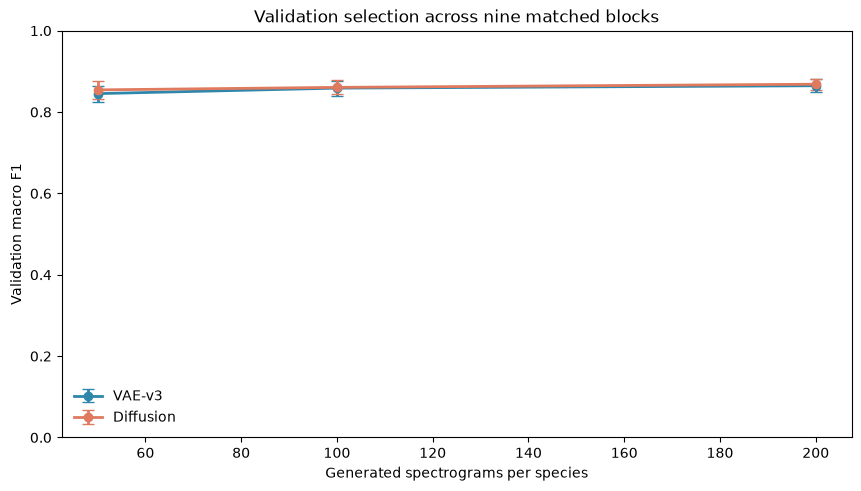

VAE-v3 selected +200 per species from validation.
Diffusion selected +200 per species from validation.


In [9]:
validation_view = low_validation[[
    'generator', 'ratio_per_species', 'runs', 'validation_macro_f1_mean',
    'validation_macro_f1_sample_sd', 'validation_macro_f1_min',
    'validation_macro_f1_max', 'selected_for_test',
]].copy()
validation_view['generator'] = validation_view['generator'].map(MODEL_LABELS)
validation_view = validation_view.rename(columns={
    'generator': 'Generator', 'ratio_per_species': 'Generated/species', 'runs': 'Runs',
    'validation_macro_f1_mean': 'Mean macro F1',
    'validation_macro_f1_sample_sd': 'Sample SD',
    'validation_macro_f1_min': 'Minimum',
    'validation_macro_f1_max': 'Maximum',
    'selected_for_test': 'Selected',
})
display(validation_view.style.format({
    'Mean macro F1': '{:.2%}', 'Sample SD': '{:.2%}',
    'Minimum': '{:.2%}', 'Maximum': '{:.2%}',
}))

figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
for model in MODEL_ORDER:
    label = MODEL_LABELS[model]
    ordered = validation_view[validation_view['Generator'] == label].sort_values('Generated/species')
    axis.errorbar(
        ordered['Generated/species'], ordered['Mean macro F1'],
        yerr=ordered['Sample SD'], marker='o', capsize=4, linewidth=2,
        color=GENERATOR_COLORS[model], label=label,
    )
axis.set(
    xlabel='Generated spectrograms per species', ylabel='Validation macro F1',
    ylim=(0, 1), title='Validation selection across nine matched blocks',
)
axis.legend(frameon=False)
plt.show()
for model in MODEL_ORDER:
    print(f'{MODEL_LABELS[model]} selected +{selected_ratios[model]} per species from validation.')

### Held-out paired CRNN utility

The primary comparison is paired within each real-subset/training-seed block. The deterministic bootstrap interval summarizes the nine matched block effects; it is not a p-value, a confidence interval over test recordings, or evidence from nine independent datasets.

In [10]:
aggregate_view = low_test_aggregate[[
    'condition', 'runs', 'accuracy_mean', 'accuracy_sample_sd',
    'macro_f1_mean', 'macro_f1_sample_sd', 'macro_f1_min', 'macro_f1_max',
    'minimum_species_recall_mean',
]].copy()
aggregate_view['condition'] = aggregate_view['condition'].map(LOW_RESOURCE_CONDITION_LABELS)
aggregate_view = aggregate_view.rename(columns={
    'condition': 'Condition', 'runs': 'Runs', 'accuracy_mean': 'Mean accuracy',
    'accuracy_sample_sd': 'Accuracy SD', 'macro_f1_mean': 'Mean macro F1',
    'macro_f1_sample_sd': 'Macro-F1 SD', 'macro_f1_min': 'Macro-F1 minimum',
    'macro_f1_max': 'Macro-F1 maximum',
    'minimum_species_recall_mean': 'Mean worst-species recall',
})
display(aggregate_view.style.format({
    column: '{:.2%}' for column in aggregate_view.columns if column not in {'Condition', 'Runs'}
}))

paired_view = low_paired_summary[[
    'generator', 'selected_ratio_per_species', 'paired_blocks',
    'delta_macro_f1_mean', 'delta_macro_f1_sample_sd',
    'delta_macro_f1_min', 'delta_macro_f1_max',
    'delta_macro_f1_bootstrap_95_low', 'delta_macro_f1_bootstrap_95_high',
    'delta_macro_f1_positive_blocks',
]].copy()
paired_view['generator'] = paired_view['generator'].map(MODEL_LABELS)
paired_view = paired_view.rename(columns={
    'generator': 'Generator', 'selected_ratio_per_species': 'Selected generated/species',
    'paired_blocks': 'Blocks', 'delta_macro_f1_mean': 'Mean paired delta',
    'delta_macro_f1_sample_sd': 'Delta SD', 'delta_macro_f1_min': 'Minimum delta',
    'delta_macro_f1_max': 'Maximum delta',
    'delta_macro_f1_bootstrap_95_low': 'Interval low',
    'delta_macro_f1_bootstrap_95_high': 'Interval high',
    'delta_macro_f1_positive_blocks': 'Positive blocks',
})
display(paired_view.style.format({
    'Mean paired delta': '{:+.2%}', 'Delta SD': '{:.2%}',
    'Minimum delta': '{:+.2%}', 'Maximum delta': '{:+.2%}',
    'Interval low': '{:+.2%}', 'Interval high': '{:+.2%}',
}))

,Condition,Runs,Mean accuracy,Accuracy SD,Mean macro F1,Macro-F1 SD,Macro-F1 minimum,Macro-F1 maximum,Mean worst-species recall
0,Real only,9,84.78%,2.42%,84.75%,2.52%,81.02%,90.00%,75.38%
1,VAE-v3 +200,9,87.48%,1.92%,87.48%,2.07%,83.07%,90.03%,79.62%
2,Diffusion +200,9,86.18%,1.05%,86.21%,1.04%,84.80%,88.10%,82.32%


,Generator,Selected generated/species,Blocks,Mean paired delta,Delta SD,Minimum delta,Maximum delta,Interval low,Interval high,Positive blocks
0,Diffusion,200,9,+1.46%,2.26%,-1.90%,+5.75%,+0.15%,+2.89%,6
1,VAE-v3,200,9,+2.72%,2.95%,-1.04%,+8.13%,+1.00%,+4.65%,7


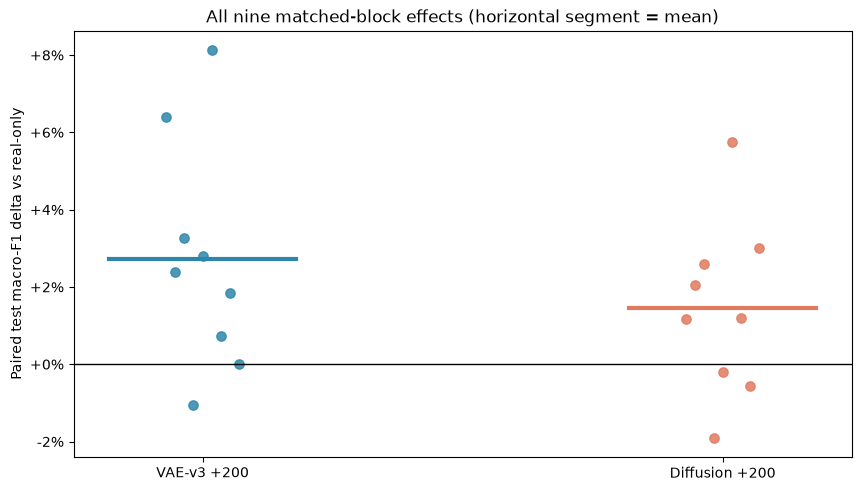

,Generator,Real-subset seed,CRNN seed,Pool seed,Paired macro-F1 delta
0,VAE-v3,101,42,42.000000,+6.40%
1,VAE-v3,101,123,123.000000,+2.39%
2,VAE-v3,101,777,777.000000,+3.26%
3,VAE-v3,202,42,123.000000,-1.04%
4,VAE-v3,202,123,777.000000,+2.81%
5,VAE-v3,202,777,42.000000,+8.13%
6,VAE-v3,303,42,777.000000,+0.74%
7,VAE-v3,303,123,42.000000,+1.84%
8,VAE-v3,303,777,123.000000,-0.00%
9,Diffusion,101,42,42.000000,+1.17%


In [11]:
plot_data = low_paired.copy()
plot_data['Generator'] = plot_data['generator'].map(MODEL_LABELS)
figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
positions = {MODEL_LABELS[model]: index for index, model in enumerate(MODEL_ORDER)}
axis.axhline(0, color='black', linewidth=1)
for model in MODEL_ORDER:
    label = MODEL_LABELS[model]
    group = plot_data[plot_data['Generator'] == label]
    x = positions[label]
    jitter = np.linspace(-0.07, 0.07, len(group))
    axis.scatter(
        np.full(len(group), x) + jitter, group['delta_macro_f1'],
        s=45, alpha=0.85, color=GENERATOR_COLORS[model], label=label,
    )
    axis.plot(
        [x - 0.18, x + 0.18], [group['delta_macro_f1'].mean()] * 2,
        linewidth=3, color=GENERATOR_COLORS[model],
    )
axis.set(
    xticks=list(positions.values()),
    xticklabels=[f'{MODEL_LABELS[model]} +{selected_ratios[model]}' for model in MODEL_ORDER],
    ylabel='Paired test macro-F1 delta vs real-only',
    title='All nine matched-block effects (horizontal segment = mean)',
)
axis.yaxis.set_major_formatter(lambda value, position: f'{value:+.0%}')
plt.show()

block_view = low_paired[[
    'generator', 'real_subset_seed', 'train_seed', 'pool_seed', 'delta_macro_f1',
]].copy()
block_view['generator'] = block_view['generator'].map(MODEL_LABELS)
block_view = block_view.rename(columns={
    'generator': 'Generator', 'real_subset_seed': 'Real-subset seed',
    'train_seed': 'CRNN seed', 'pool_seed': 'Pool seed',
    'delta_macro_f1': 'Paired macro-F1 delta',
})
display(block_view.style.format({'Paired macro-F1 delta': '{:+.2%}'}))

### Species recall

Macro F1 gives each species equal weight but can hide which class changes. This table compares mean recall across the same nine blocks.

,Condition,Species,Mean recall,Delta vs real-only
0,Real only,American Robin,90.57%,+0.00%
1,VAE-v3 +200,American Robin,94.79%,+4.21%
2,Diffusion +200,American Robin,88.66%,-1.92%
3,Real only,Northern Cardinal,75.38%,+0.00%
4,VAE-v3 +200,Northern Cardinal,80.52%,+5.14%
5,Diffusion +200,Northern Cardinal,82.51%,+7.13%
6,Real only,Song Sparrow,88.52%,+0.00%
7,VAE-v3 +200,Song Sparrow,87.85%,-0.67%
8,Diffusion +200,Song Sparrow,87.48%,-1.04%


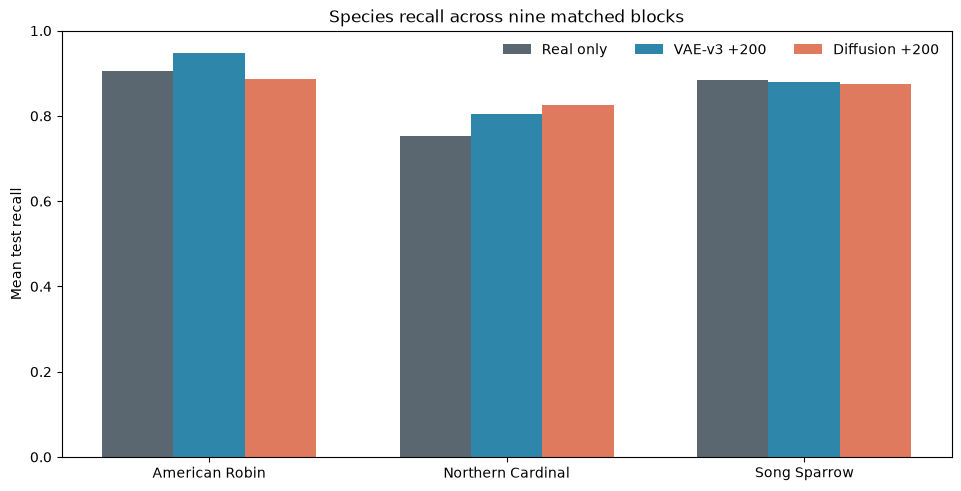

In [12]:
species_columns = {
    'recall_american_robin_mean': 'American Robin',
    'recall_northern_cardinal_mean': 'Northern Cardinal',
    'recall_song_sparrow_mean': 'Song Sparrow',
}
species_view = low_test_aggregate[['condition', *species_columns]].copy()
species_view['condition'] = species_view['condition'].map(LOW_RESOURCE_CONDITION_LABELS)
species_view = species_view.rename(columns={'condition': 'Condition', **species_columns})
baseline_recall = species_view.loc[species_view['Condition'] == 'Real only'].iloc[0]
species_long = species_view.melt(
    id_vars='Condition', var_name='Species', value_name='Mean recall'
)
species_long['Delta vs real-only'] = species_long.apply(
    lambda row: row['Mean recall'] - baseline_recall[row['Species']], axis=1
)
display(species_long.style.format({
    'Mean recall': '{:.2%}', 'Delta vs real-only': '{:+.2%}',
}))

figure, axis = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
species_names = list(species_columns.values())
x = np.arange(len(species_names))
width = 0.24
for index, (_, row) in enumerate(species_view.iterrows()):
    values = [row[name] for name in species_names]
    axis.bar(
        x + (index - 1) * width, values, width,
        label=row['Condition'], color=LOW_RESOURCE_COLORS[row['Condition']],
    )
axis.set(
    xticks=x, xticklabels=species_names, ylabel='Mean test recall', ylim=(0, 1),
    title='Species recall across nine matched blocks',
)
axis.legend(frameon=False, ncols=3)
plt.show()

### Part 2 result and limitations

The next cell derives the final result statement from the hardened report. The design simulates classifier-label scarcity for three common species; the pretrained generators saw more source data, the real subsets overlap, pool seed is rotated rather than fully crossed, the project test set is not a new external holdout, and the largest tested ratio is not necessarily the optimum.

In [13]:
low_aggregate_index = low_test_aggregate.set_index('condition')
low_paired_index = low_paired_summary.set_index('generator')
baseline_macro_f1 = float(low_aggregate_index.loc['real_only', 'macro_f1_mean'])
low_resource_result_records = []
for model in MODEL_ORDER:
    condition_code = condition_codes[model]
    paired_row = low_paired_index.loc[model]
    interval_low = float(paired_row['delta_macro_f1_bootstrap_95_low'])
    interval_high = float(paired_row['delta_macro_f1_bootstrap_95_high'])
    if interval_low > 0:
        interval_position = 'entirely above zero'
    elif interval_high < 0:
        interval_position = 'entirely below zero'
    else:
        interval_position = 'spans zero'
    low_resource_result_records.append({
        'Generator': MODEL_LABELS[model],
        'Selected generated/species': selected_ratios[model],
        'Real-only macro F1': baseline_macro_f1,
        'Synthetic-arm macro F1': float(low_aggregate_index.loc[condition_code, 'macro_f1_mean']),
        'Mean paired delta': float(paired_row['delta_macro_f1_mean']),
        'Interval low': interval_low,
        'Interval high': interval_high,
        'Positive blocks': int(paired_row['delta_macro_f1_positive_blocks']),
        'Interval position': interval_position,
    })
low_resource_results = pd.DataFrame(low_resource_result_records)
assert np.allclose(
    low_resource_results['Synthetic-arm macro F1']
    - low_resource_results['Real-only macro F1'],
    low_resource_results['Mean paired delta'],
    atol=1e-12,
)
display(low_resource_results.style.format({
    'Real-only macro F1': '{:.2%}', 'Synthetic-arm macro F1': '{:.2%}',
    'Mean paired delta': '{:+.2%}', 'Interval low': '{:+.2%}',
    'Interval high': '{:+.2%}',
}))
for _, row in low_resource_results.iterrows():
    print(
        f"{row['Generator']} +{int(row['Selected generated/species'])}/species: "        f"paired macro-F1 delta {row['Mean paired delta']:+.2%}, interval "        f"{row['Interval low']:+.2%} to {row['Interval high']:+.2%}; "        f"{row['Interval position']}."
    )

,Generator,Selected generated/species,Real-only macro F1,Synthetic-arm macro F1,Mean paired delta,Interval low,Interval high,Positive blocks,Interval position
0,VAE-v3,200,84.75%,87.48%,+2.72%,+1.00%,+4.65%,7,entirely above zero
1,Diffusion,200,84.75%,86.21%,+1.46%,+0.15%,+2.89%,6,entirely above zero


VAE-v3 +200/species: paired macro-F1 delta +2.72%, interval +1.00% to +4.65%; entirely above zero.
Diffusion +200/species: paired macro-F1 delta +1.46%, interval +0.15% to +2.89%; entirely above zero.


### Reproduction boundary

The matched experiment is implemented by `scripts/15_crnn_low_resource_augmentation.py`. From the repository root:

```powershell
$env:PYTHONPATH = (Resolve-Path 'src').Path
& ..\bird_song_venv\Scripts\python.exe `
  scripts/15_crnn_low_resource_augmentation.py audit
& ..\bird_song_venv\Scripts\python.exe `
  scripts/15_crnn_low_resource_augmentation.py run --device cuda --workers 0
```

The command trains only the matched CRNN conditions and promotes bounded report evidence. It does not generate VAE or diffusion pools; the packaged pool provenance records the earlier VAE refresh and retained diffusion pools.

## Part 3 - Matched generator-only speed comparison

**Question.** Under an equal-count, equal-batch, same-precision generator-only benchmark on the same CUDA device, how do VAE-v3 and DDIM diffusion sampling times compare?

This section reads `reports/generator_speed_comparison_2026-08-12/`. The completed diffusion timing was retained; VAE-v3 was remeasured later with the filtered 759-anchor bank, and no diffusion sampling was rerun. The benchmark excludes checkpoint loading, classifier-scale conversion, CPU transfer, file I/O, waveform decoding, and WAV writing. It is a sequential system measurement, not a quality score.

In [14]:
SPEED_REPORT_ROOT = PROJECT_ROOT / 'reports' / 'generator_speed_comparison_2026-08-12'
required_speed_files = [
    'summary.json', 'repeat_results.csv',
    'vae_v3_benchmark.json', 'diffusion_benchmark.json',
]
missing_speed_files = [
    name for name in required_speed_files if not (SPEED_REPORT_ROOT / name).is_file()
]
if missing_speed_files:
    raise FileNotFoundError(
        'Fresh generator-speed report is not complete. Package it before executing this notebook; '
        f'missing: {missing_speed_files}'
    )

speed_summary = json.loads((SPEED_REPORT_ROOT / 'summary.json').read_text(encoding='utf-8'))
speed_repeats = pd.read_csv(SPEED_REPORT_ROOT / 'repeat_results.csv')
speed_benchmarks = {
    'vae_v3': json.loads((SPEED_REPORT_ROOT / 'vae_v3_benchmark.json').read_text(encoding='utf-8')),
    'diffusion': json.loads((SPEED_REPORT_ROOT / 'diffusion_benchmark.json').read_text(encoding='utf-8')),
}

assert speed_summary['schema_version'] == 1
assert set(speed_summary['models']) == set(MODEL_ORDER)
assert set(speed_repeats['model']) == set(MODEL_ORDER)
assert speed_summary['cuda_synchronized'] is True
assert speed_summary['sample_count_per_repeat'] == speed_summary['samples_per_species'] * 3
assert len(speed_repeats) == speed_summary['repeat_count_per_model'] * len(MODEL_ORDER)
assert speed_repeats['sample_count'].eq(speed_summary['sample_count_per_repeat']).all()
assert speed_repeats['seconds'].gt(0).all()
assert speed_repeats['samples_per_second'].gt(0).all()
expected_measurement_sequence_note = (
    'The completed diffusion benchmark was retained; VAE-v3 was remeasured afterward '
    'using the filtered 759-anchor bank. No diffusion sampling was rerun.'
)
assert speed_summary['measurement_sequence_note'] == expected_measurement_sequence_note
assert 'models were benchmarked sequentially rather than interleaved' in (
    speed_summary['interpretation_boundary']
)

matched_fields = [
    'samples_per_species', 'samples_per_repeat', 'classes', 'balanced_by_species',
    'batch_size', 'precision', 'warmup_batches', 'repeat_count', 'timing_boundary',
]
hardware_fields = [
    'device', 'torch_version', 'cuda_runtime', 'cuda_device_index',
    'cuda_device_name', 'cuda_capability', 'cuda_total_memory_bytes',
]
for model, benchmark in speed_benchmarks.items():
    assert benchmark['schema_version'] == 1
    assert benchmark['benchmark_type'] == 'generator_only_cuda_synchronized'
    assert benchmark['generator'] == model
    assert benchmark['existing_arrays_used'] is False
    assert benchmark['fresh_in_memory_generation_each_repeat'] is True
    assert benchmark['cuda_synchronized'] is True
    assert len(benchmark['repeat_results']) == benchmark['repeat_count']
vae_speed_settings = speed_benchmarks['vae_v3']['settings']
assert vae_speed_settings['temperature'] == 0.35
assert vae_speed_settings['reparameterization'] == quality_vae_contract['reparameterization']
assert vae_speed_settings['posterior_bank_contract'] == quality_vae_contract['posterior_bank_contract']
assert vae_speed_settings['posterior_bank_counts'] == quality_vae_contract['posterior_bank_counts']
assert vae_speed_settings['vae_checkpoint_retrained'] is False
assert sum(vae_speed_settings['posterior_bank_counts'].values()) == 759
diffusion_speed_settings = speed_benchmarks['diffusion']['settings']
for key in (
    'sampler', 'timesteps', 'ddim_steps', 'ddim_eta', 'guidance_weight',
    'clamp_samples', 'checkpoint_epoch', 'checkpoint_selection',
    'stored_sampler_overridden',
):
    assert diffusion_speed_settings[key] == quality_diffusion_contract[key]
for field in matched_fields:
    assert speed_benchmarks['vae_v3'][field] == speed_benchmarks['diffusion'][field], field
for field in hardware_fields:
    assert (
        speed_benchmarks['vae_v3']['hardware'][field]
        == speed_benchmarks['diffusion']['hardware'][field]
    ), field

speed_protocol_table = pd.DataFrame([
    {'item': 'Samples per species / repeat', 'recorded value': speed_summary['samples_per_species']},
    {'item': 'Total samples / repeat', 'recorded value': speed_summary['sample_count_per_repeat']},
    {'item': 'Repeats / model', 'recorded value': speed_summary['repeat_count_per_model']},
    {'item': 'Warm-up batches / model', 'recorded value': speed_summary['warmup_batches_per_model']},
    {'item': 'Batch size', 'recorded value': speed_summary['batch_size']},
    {'item': 'Precision', 'recorded value': speed_summary['precision']},
    {'item': 'CUDA device', 'recorded value': speed_summary['hardware']['cuda_device_name']},
    {'item': 'Measurement sequence', 'recorded value': speed_summary['measurement_sequence_note']},
    {'item': 'Timing boundary', 'recorded value': speed_summary['timing_boundary']},
])
display(speed_protocol_table)

,item,recorded value
0,Samples per species / repeat,200
1,Total samples / repeat,600
2,Repeats / model,5
3,Warm-up batches / model,5
4,Batch size,8
5,Precision,float32
6,CUDA device,NVIDIA GeForce RTX 4070 SUPER
7,Measurement sequence,The completed diffusion benchmark was retained...
8,Timing boundary,fresh in-memory generator sampling only; inclu...


### Speed result

The next cell derives timing and throughput statements from the finalized report while preserving the recorded sequential measurement boundary.

,Model,Mean seconds,Seconds sample SD,Minimum seconds,Maximum seconds,Mean spectrograms/s,Throughput sample SD,Peak CUDA memory GiB
0,VAE-v3,0.3058,0.0096,0.2975,0.3212,1963.276,60.208,0.185
1,Diffusion,412.3090,2.8120,410.8606,417.3315,1.455,0.010,0.333


,model,repeat,sample_count,seconds,samples_per_second,peak_cuda_memory_bytes,incremental_peak_cuda_memory_bytes
5,diffusion,1,600,417.3315,1.438,357850112,272641536
6,diffusion,2,600,410.8606,1.460,357850112,272641536
7,diffusion,3,600,411.1814,1.459,357850112,272641536
8,diffusion,4,600,411.2319,1.459,357850112,272641536
9,diffusion,5,600,410.9396,1.460,357850112,272641536
0,vae_v3,1,600,0.2983,2011.465,199008768,75867136
1,vae_v3,2,600,0.3076,1950.398,199008768,75867136
2,vae_v3,3,600,0.3046,1970.093,199008768,75867136
3,vae_v3,4,600,0.2975,2016.637,199008768,75867136
4,vae_v3,5,600,0.3212,1867.786,199008768,75867136


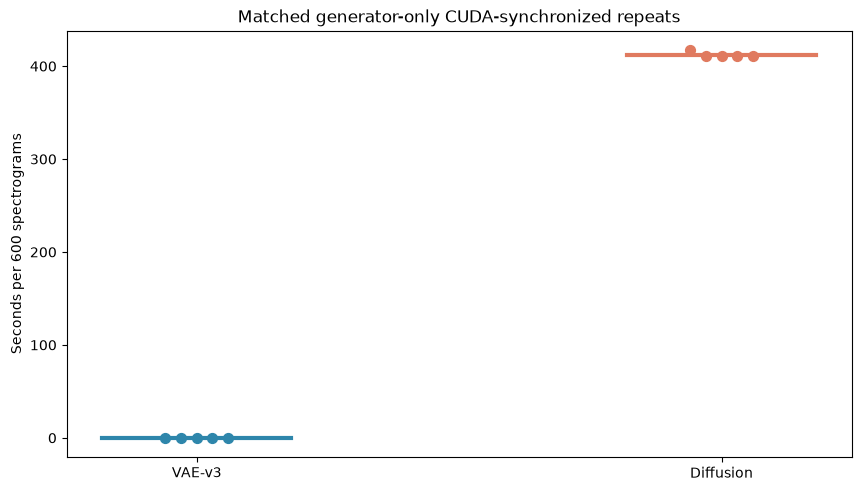

,absolute_seconds_difference,diffusion_to_vae_time_ratio,vae_to_diffusion_throughput_ratio
0,+412.0032,1348.089x,1349.078x


Diffusion/VAE generator-time ratio: 1348.089x; VAE/diffusion throughput ratio: 1349.078x.


In [15]:
speed_model_records = []
for model in MODEL_ORDER:
    values = speed_summary['models'][model]
    speed_model_records.append({
        'Model': MODEL_LABELS[model],
        'Mean seconds': values['seconds_mean'],
        'Seconds sample SD': values['seconds_sample_sd'],
        'Minimum seconds': values['seconds_min'],
        'Maximum seconds': values['seconds_max'],
        'Mean spectrograms/s': values['samples_per_second_mean'],
        'Throughput sample SD': values['samples_per_second_sample_sd'],
        'Peak CUDA memory GiB': values['peak_cuda_memory_bytes_max'] / 2**30,
    })
speed_model_results = pd.DataFrame(speed_model_records)
display(speed_model_results.style.format({
    'Mean seconds': '{:.4f}', 'Seconds sample SD': '{:.4f}',
    'Minimum seconds': '{:.4f}', 'Maximum seconds': '{:.4f}',
    'Mean spectrograms/s': '{:.3f}', 'Throughput sample SD': '{:.3f}',
    'Peak CUDA memory GiB': '{:.3f}',
}))

display(speed_repeats.sort_values(['model', 'repeat']).style.format({
    'seconds': '{:.4f}', 'samples_per_second': '{:.3f}',
}))

figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
for index, model in enumerate(MODEL_ORDER):
    values = speed_repeats.loc[speed_repeats['model'] == model, 'seconds'].to_numpy()
    jitter = np.linspace(-0.06, 0.06, len(values))
    axis.scatter(
        np.full(len(values), index) + jitter, values, s=50,
        color=GENERATOR_COLORS[model], label=MODEL_LABELS[model],
    )
    axis.plot(
        [index - 0.18, index + 0.18], [values.mean(), values.mean()],
        linewidth=3, color=GENERATOR_COLORS[model],
    )
axis.set(
    xticks=range(len(MODEL_ORDER)),
    xticklabels=[MODEL_LABELS[model] for model in MODEL_ORDER],
    ylabel=f'Seconds per {speed_summary["sample_count_per_repeat"]} spectrograms',
    title='Matched generator-only CUDA-synchronized repeats',
)
plt.show()

speed_comparison = pd.DataFrame([speed_summary['comparison']])
vae_seconds = float(speed_summary['models']['vae_v3']['seconds_mean'])
diffusion_seconds = float(speed_summary['models']['diffusion']['seconds_mean'])
reported_comparison = speed_summary['comparison']
assert np.isclose(
    reported_comparison['absolute_seconds_difference'],
    diffusion_seconds - vae_seconds,
)
assert np.isclose(
    reported_comparison['diffusion_to_vae_time_ratio'],
    diffusion_seconds / vae_seconds,
)
display(speed_comparison.style.format({
    'absolute_seconds_difference': '{:+.4f}',
    'diffusion_to_vae_time_ratio': '{:.3f}x',
    'vae_to_diffusion_throughput_ratio': '{:.3f}x',
}))
print(
    'Diffusion/VAE generator-time ratio: '
    f"{speed_summary['comparison']['diffusion_to_vae_time_ratio']:.3f}x; "
    'VAE/diffusion throughput ratio: '
    f"{speed_summary['comparison']['vae_to_diffusion_throughput_ratio']:.3f}x."
)

### Part 3 evidence boundary

This comparison supports only generator-side spectrogram sampling latency and memory statements on the recorded hardware under the matched settings. It excludes loading, conversion, transfer, serialization, report I/O, waveform decoding, and audio writing. Because the models were measured sequentially rather than interleaved, the recorded ratio is a system-specific comparison. Runtime must remain separate from generator quality and downstream CRNN utility.

## Final evidence-bound conclusion

The three parts answer different questions and must not be pooled into a composite winner. The following table is generated only from refreshed report rows.

In [16]:
part1_headline = '; '.join(
    f"{MODEL_LABELS[row.model]} CRNN macro F1 {row.macro_f1_mean:.2%} "
    f"(seed range {row.macro_f1_min:.2%} to {row.macro_f1_max:.2%})"
    for row in part1_model_summary.sort_values('model').itertuples(index=False)
)
part2_headline = '; '.join(
    f"{row['Generator']} +{int(row['Selected generated/species'])}/species paired delta "
    f"{row['Mean paired delta']:+.2%} "
    f"({row['Interval low']:+.2%} to {row['Interval high']:+.2%})"
    for _, row in low_resource_results.iterrows()
)
part3_headline = (
    f"Diffusion/VAE time ratio "
    f"{speed_summary['comparison']['diffusion_to_vae_time_ratio']:.3f}x; "
    f"VAE/diffusion throughput ratio "
    f"{speed_summary['comparison']['vae_to_diffusion_throughput_ratio']:.3f}x"
)
evidence_summary = pd.DataFrame([
    {
        'Part': '1 - CRNN-only generator quality',
        'Question': 'Are refreshed pools classifier-compatible and stable?',
        'Code-derived evidence': part1_headline,
        'Claim boundary': 'CRNN/feature-space and array diagnostics only',
    },
    {
        'Part': '2 - Matched low-resource utility',
        'Question': 'Do selected generated additions help 50-real/species CRNNs?',
        'Code-derived evidence': part2_headline,
        'Claim boundary': 'Paired nine-block simulated label scarcity only',
    },
    {
        'Part': '3 - Generator-only speed',
        'Question': 'How do matched generator-side runtimes compare?',
        'Code-derived evidence': part3_headline,
        'Claim boundary': 'Recorded hardware and timing boundary only',
    },
])
display(evidence_summary)

,Part,Question,Code-derived evidence,Claim boundary
0,1 - CRNN-only generator quality,Are refreshed pools classifier-compatible and ...,Diffusion CRNN macro F1 92.42% (seed range 91....,CRNN/feature-space and array diagnostics only
1,2 - Matched low-resource utility,Do selected generated additions help 50-real/s...,VAE-v3 +200/species paired delta +2.72% (+1.00...,Paired nine-block simulated label scarcity only
2,3 - Generator-only speed,How do matched generator-side runtimes compare?,Diffusion/VAE time ratio 1348.089x; VAE/diffus...,Recorded hardware and timing boundary only


### Interpretation rule

This notebook is executed against the finalized report packages. A generator may score well in CRNN feature space without improving the matched low-resource classifier, and a faster generator is not necessarily higher quality. Preserve the nine-block caveats, the classifier-view limitation, and the sequential generator-only timing boundary in any presentation conclusion.